In [27]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
def parse_params(params_str):
    params = {}
    for item in params_str.split():
        if '=' in item:
            key, value = item.split('=', 1)
            params[key] = value
    return params

# aggregates results over all parameters except those in params_to_compare
def results_csv_to_df(csv_file, params_to_aggregate=None):
    results = []

    with open(csv_file, newline='') as f:
        reader = csv.DictReader(f, fieldnames=[
            'accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed', 'not_fully_unmasked',
            'checkpoint', 'strategy', 'params'
        ])
        reader.__next__()  # Skip header row
        for row in reader:
            params = parse_params(row['params'])
            row_dict = {
                'accuracy': float(row['accuracy']),
                'correctly_filled_cells': float(row['correctly_filled_cells']),
                'checkpoint': row['checkpoint'],
                'strategy': row['strategy'],
                'nfe': float(row['nfe']),
                'time': float(row['time']),
                'speed': float(row['speed']),
            }
            row_dict.update(params.items())
            results.append(row_dict)
    
    results_df = pd.DataFrame(results)
    print(f"Total rows before aggregation: {len(results_df)}")
    
    # Aggregate the accuracy, correctly_filled_cells, nfe, time, and speed over the rows where all parameters except those in params_to_aggregate are the same
    if params_to_aggregate is not None:
        groupby_cols = [col for col in results_df.columns if col not in params_to_aggregate + ['accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed']]
    else:
        groupby_cols = [col for col in results_df.columns if col not in ['accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed']]
    
    aggregated_df = results_df.groupby(groupby_cols, dropna=False).agg(
        accuracy_mean=pd.NamedAgg(column='accuracy', aggfunc='mean'),
        accuracy_std=pd.NamedAgg(column='accuracy', aggfunc='std'),
        correctly_filled_cells_mean=pd.NamedAgg(column='correctly_filled_cells', aggfunc='mean'),
        correctly_filled_cells_std=pd.NamedAgg(column='correctly_filled_cells', aggfunc='std'),
        nfe=pd.NamedAgg(column='nfe', aggfunc='mean'),
        time=pd.NamedAgg(column='time', aggfunc='mean'),
        speed=pd.NamedAgg(column='speed', aggfunc='mean'),
    ).reset_index()

    print(f"Rows after aggregation: {len(aggregated_df)}")
    return aggregated_df

In [29]:
params_to_aggregate = ['seed']
df = results_csv_to_df('results_vary_num_parallel_beams.csv', params_to_aggregate=params_to_aggregate)
df

Total rows before aggregation: 16
Rows after aggregation: 16


,checkpoint,strategy,score_position_for_change,select_position,change_token,k,gumbel_noise_coefficient,self_correction,dataset,num_samples,...,position_sampling,position_metric,token_sampling,accuracy_mean,accuracy_std,correctly_filled_cells_mean,correctly_filled_cells_std,nfe,time,speed
0,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.6872,NaN,0.8572,NaN,95.19,7026.0,0.91
1,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.7044,NaN,0.8641,NaN,114.11,9957.0,0.64
2,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.7373,NaN,0.8780,NaN,242.27,17765.0,0.36
3,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,change_max,top_k_gumbel,change_max,1,0,none,hard,6400,...,NaN,NaN,NaN,0.7670,NaN,0.8896,NaN,335.38,24986.0,0.26
4,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,NaN,NaN,change_max,1,0,NaN,hard,6400,...,NaN,NaN,NaN,0.6905,NaN,0.8582,NaN,103.28,7973.0,0.80
5,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,NaN,NaN,change_max,1,0,NaN,hard,6400,...,NaN,NaN,NaN,0.7102,NaN,0.8665,NaN,131.96,11832.0,0.54
6,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,NaN,NaN,change_max,1,0,NaN,hard,6400,...,NaN,NaN,NaN,0.7442,NaN,0.8799,NaN,279.09,21649.0,0.30
7,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,NaN,NaN,change_max,1,0,NaN,hard,6400,...,NaN,NaN,NaN,0.7777,NaN,0.8933,NaN,408.51,31356.0,0.20
8,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,NaN,NaN,NaN,1,NaN,NaN,hard,6400,...,top_k,margin,max,0.6855,NaN,0.8569,NaN,99.18,7855.0,0.81
9,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,NaN,NaN,NaN,1,NaN,NaN,hard,6400,...,top_k,margin,max,0.7044,NaN,0.8649,NaN,118.43,11112.0,0.58


In [30]:
grouped_df = df.groupby(['checkpoint', 'strategy', 'pruning_num_beams', 'branching_factor', 'dataset'])['accuracy_mean'].mean().unstack()#.sort_values(by='accuracy_mean')
grouped_df

dataset                                                                                                               hard
checkpoint                      strategy                                        pruning_num_beams branching_factor        
checkpoints/gidd_0_2/300_epochs gidd_change_based_on_model_confidence_to_change 1                 2                 0.6872
                                                                                2                 2                 0.7044
                                                                                                  4                 0.7373
                                                                                4                 4                 0.7670
                                gidd_change_low_confidence_positions            1                 2                 0.6905
                                                                                2                 2                 0.7102
                                                                                                  4                 0.7442
                                                                                4                 4                 0.7777
                                gidd_prob_to_recover_data                       1                 2                 0.6855
                                                                                2                 2                 0.7044
                                                                                                  4                 0.7369
                                                                                4                 4                 0.7664
checkpoints/mdlm/300_epochs     mdlm_adaptive_score_select_update               1                 2                 0.6597
                                                                                2                 2                 0.6678
                                                                                                  4                 0.6764
                                                                                4                 4                 0.6861

In [31]:
strategy_to_label = {
    'mdlm_adaptive_score_select_update': 'MD top-k probability',
    'gidd_change_based_on_model_confidence_to_change': 'Mask current probability',
    'gidd_change_low_confidence_positions': 'Change low confidence positions',
}

In [32]:
def plot_subset(x_axis, subset, label, strategy_color, marker, linestyle):
    if not subset.empty:
        # Sort by NFE for proper line connection
        subset_sorted = subset.sort_values(x_axis)
        plt.plot(subset_sorted[x_axis], subset_sorted['accuracy_mean'], 
                label=label,
                marker=marker,
                color=strategy_color,
                linestyle=linestyle,
                markersize=6, alpha=0.7, linewidth=2)

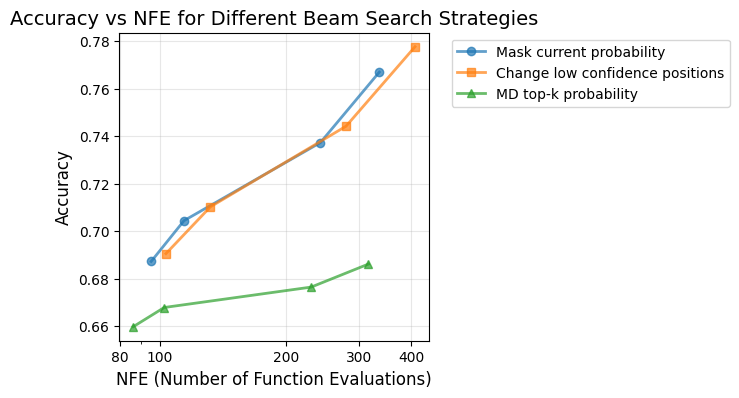

In [40]:
# Plot accuracy vs NFE for each strategy

# Filter data
filtered_data = df
# filtered_data = df[df['do_beam_search'] == 'true']
# filtered_data = df[df['do_beam_search'] == 'false']
filtered_data = df[df['strategy'] != 'gidd_prob_to_recover_data']

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
df_by_category = {
    'independent': filtered_data[
        (filtered_data['strategy'].isin(['mdlm_vanilla', 'gidd_independent_positions_decomposed_update_distribution'])) |
        ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'independent'))
    ],
    'top_k': filtered_data[
        (
            (filtered_data['strategy'].isin(['mdlm_adaptive_score_select_update', 'gidd_change_low_confidence_positions', 'gidd_change_based_on_model_confidence_to_change'])) |
            ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'top_k'))
        ) & (filtered_data['do_beam_search'] == 'false')
    ],
    'beam_search': filtered_data[
        (filtered_data['do_beam_search'] == 'true')
    ]
}

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))
strategies_to_index = {strategy: idx for idx, strategy in enumerate(strategies)}

for category, category_data in df_by_category.items():
    if len(category_data) == 0:
        continue
    # print('a')
    current_strategies = category_data['strategy'].unique()
    current_checkpoints = category_data['checkpoint'].unique()
    for strategy in current_strategies:
        # print('b')
        for checkpoint in current_checkpoints:
            strategy_color = colors[strategies_to_index[strategy]]
            subset = category_data[
                (category_data['strategy'] == strategy) & 
                (category_data['checkpoint'] == checkpoint)
            ]
            if len(subset) == 0:
                continue
            # print('c')
            linestyle = '-'
            if category == 'beam_search':
                label = strategy_to_label.get(strategy, strategy)
                plot_subset('nfe', subset, label, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)
            

plt.xlabel('NFE (Number of Function Evaluations)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs NFE for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
plt.xticks([80, 100, 200, 300, 400], [80, 100, 200, 300, 400])
# plt.tight_layout()
plt.show()


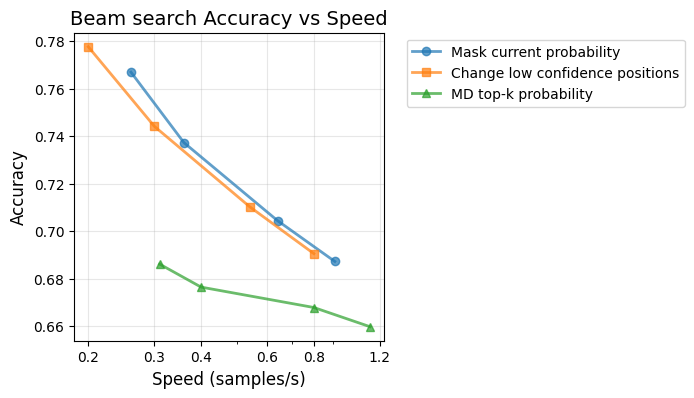

In [ ]:
# Plot accuracy vs speed for each strategy with specific filtering

# Filter data
filtered_data = df
# filtered_data = df[df['do_beam_search'] == 'true']
# filtered_data = df[df['do_beam_search'] == 'false']
filtered_data = df[df['strategy'] != 'gidd_prob_to_recover_data']

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
df_by_category = {
    'independent': filtered_data[
        (filtered_data['strategy'].isin(['mdlm_vanilla', 'gidd_independent_positions_decomposed_update_distribution'])) |
        ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'independent'))
    ],
    'top_k': filtered_data[
        (
            (filtered_data['strategy'].isin(['mdlm_adaptive_score_select_update', 'gidd_change_low_confidence_positions', 'gidd_change_based_on_model_confidence_to_change'])) |
            ((filtered_data['strategy'] == 'gidd_prob_to_recover_data') & (filtered_data['position_sampling'] == 'top_k'))
        ) & (filtered_data['do_beam_search'] == 'false')
    ],
    'beam_search': filtered_data[
        (filtered_data['do_beam_search'] == 'true')
    ]
}

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))
strategies_to_index = {strategy: idx for idx, strategy in enumerate(strategies)}

for category, category_data in df_by_category.items():
    if len(category_data) == 0:
        continue
    # print('a')
    current_strategies = category_data['strategy'].unique()
    current_checkpoints = category_data['checkpoint'].unique()
    for strategy in current_strategies:
        # print('b')
        for checkpoint in current_checkpoints:
            strategy_color = colors[strategies_to_index[strategy]]
            subset = category_data[
                (category_data['strategy'] == strategy) & 
                (category_data['checkpoint'] == checkpoint)
            ]
            if len(subset) == 0:
                continue
            # print('c')
            linestyle = '-'
            if category == 'beam_search':
                label = strategy_to_label.get(strategy, strategy)
                plot_subset('speed', subset, label, strategy_color, markers[strategies_to_index[strategy] % len(markers)], linestyle)

plt.xlabel('Speed (samples/s)', fontsize=12)
plt.ylabel('Puzzle Accuracy', fontsize=12)
plt.title('Beam search Accuracy vs Speed', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
plt.xticks([0.2, 0.3, 0.4, 0.6, 0.8, 1.2], ['0.2', '0.3', '0.4', '0.6', '0.8', '1.2'])
# plt.tight_layout()
plt.show()
